[[ 4.    4.5 ]
 [ 4.5  13.25]]
[-1.61832061  2.54961832]


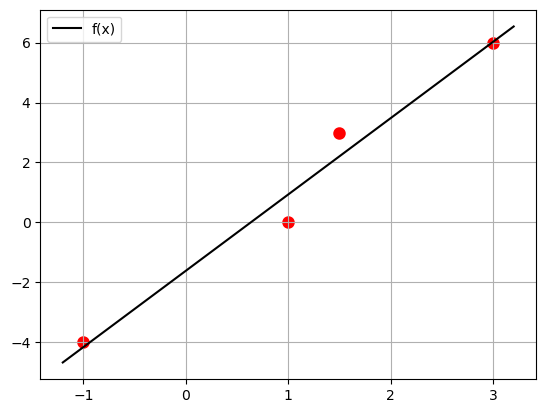

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = [-1,1,1.5,3]
y = [-4,0,3,6]

X = np.ones((4,2))
x = np.array(x)
X[:,1]=x
N = np.matmul(X.T,X)
d = np.matmul(X.T,np.array(y))
print(N)
N_inv = np.linalg.inv(N)
a = np.matmul(N_inv,d.T)
print(a)

grid_x = np.linspace(-1.2,3.2,100)
grid_y = a[0]+a[1]*grid_x

plt.figure()
plt.scatter(x,y,c='r',linewidths = 3)
plt.plot(grid_x,grid_y, c = 'black',label='f(x)')
plt.legend()
plt.grid()
plt.show()


In [ ]:
from sklearn.datasets import load_diabetes
import pandas as pd
data = load_diabetes(as_frame = True)
df = data.frame

In [ ]:
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


We konw define the covariates $X$ by selecting the body mass index, blood pressure and one blood serum. The target in this dataset is a quantitative value for the disease progression, one year after baseline.

In [ ]:
X = df[['bmi']]
y = df['target']

We now split the dataset into two parts, where we use the first one for fitting the model parameters and the second one is used for testing.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)

print('We have ', len(X_train), ' samples to fit the model and ', len(X_test) , ' samples to test it')

We have  353  samples to fit the model and  89  samples to test it


In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


We know want to know the coefficients and intercept. Additionally we want to calculate the $R^2$-score and the mean squared error on the test set.

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

y_pred = model.predict(X_test)

print("R²: ", r2_score(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test,y_pred))

R²:  0.34339782429668386
MSE:  3914.128003582026


We know visualize the predicted values and the ground truth values in a scatter plot

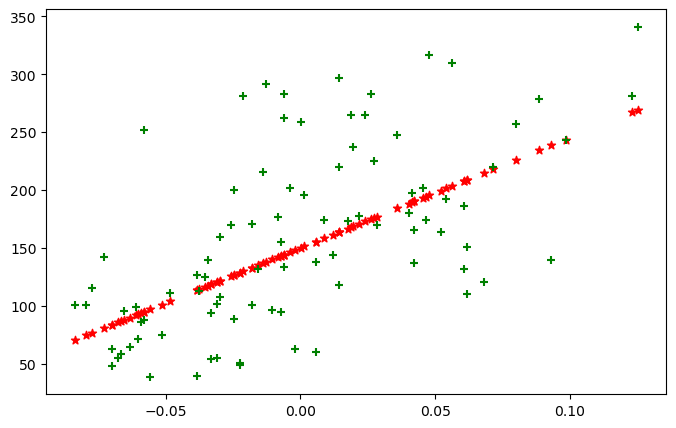

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test,y_pred, c='r',marker = '*',label = 'predicted values')
plt.scatter(X_test,y_test, c = 'g', marker = '+', label = 'ground truth values')
plt.show()

Additionally we plot the residuals to check if they are normally distributed

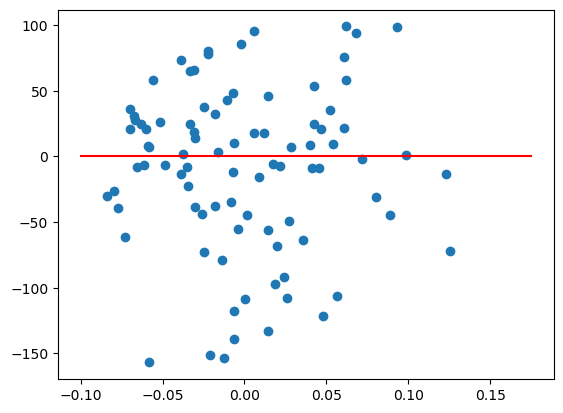

In [ ]:
res = y_pred-y_test
plt.scatter(X_test,res)
plt.plot(np.linspace(-0.1,0.175,200),np.zeros((200,)), c = 'r')
plt.show()

We now want to check how the results look if we add two other variables to the input and fit a model

In [ ]:
X = df[['bmi','bp','s5']]
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)
model = LinearRegression()
model.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [ ]:
y_pred = model.predict(X_test)

print("R²: ", r2_score(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test,y_pred))

R²:  0.39329362850619254
MSE:  2864.975025108741


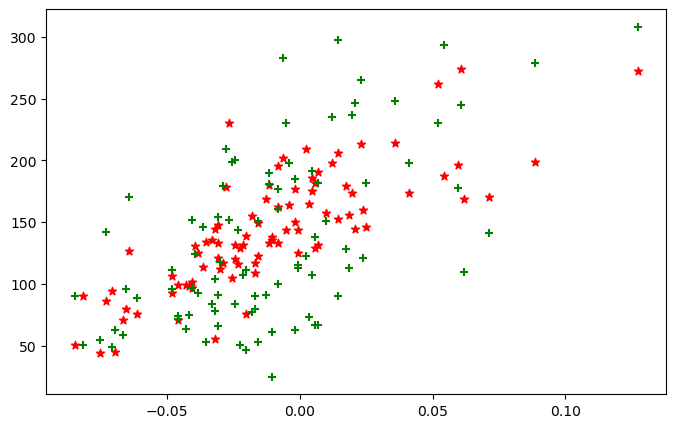

In [ ]:
plt.figure(figsize=(8, 5))
plt.scatter(X_test['bmi'],y_pred, c='r',marker = '*',label = 'predicted values')
plt.scatter(X_test['bmi'],y_test, c = 'g', marker = '+', label = 'ground truth values')
plt.show()

R²:  0.5288723947007873
MSE:  2723.164903355346


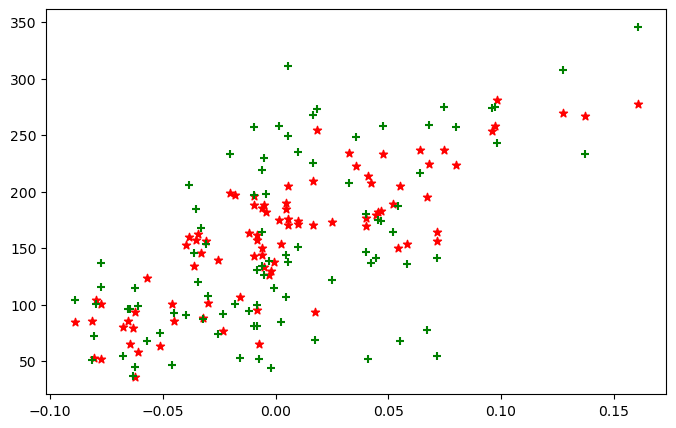

In [ ]:
X = df.loc[:,df.columns != 'target']
y = df['target']
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size = 0.2)
model = LinearRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

print("R²: ", r2_score(y_test, y_pred))
print('MSE: ', mean_squared_error(y_test,y_pred))

plt.figure(figsize=(8, 5))
plt.scatter(X_test['bmi'],y_pred, c='r',marker = '*',label = 'predicted values')
plt.scatter(X_test['bmi'],y_test, c = 'g', marker = '+', label = 'ground truth values')
plt.show()

## Logistic Regression ##

In [ ]:

from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


# Load the Iris dataset
iris = load_iris()

We use the iris dataset which contains features of plants. The plants are also categorized in three classes. We use the first two featrues as input variables and our goal is to predict the correct class

In [ ]:
X = iris.data[:, :2]  # Using first two features for easy visualization
y = iris.target

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


First we scale the data

In [ ]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


With the scaled data we can now optimize the parameters of our logistic model

In [ ]:
clf = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=200)
clf.fit(X_train, y_train)


c:\Users\johannes.schwab\AppData\Local\miniconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,200
,multi_class,'ovr'


In [ ]:
y_pred = clf.predict(X_test)

# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))


Accuracy: 0.7555555555555555

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97        15
           1       0.70      0.47      0.56        15
           2       0.63      0.80      0.71        15

    accuracy                           0.76        45
   macro avg       0.76      0.76      0.74        45
weighted avg       0.76      0.76      0.74        45


Confusion Matrix:
 [[15  0  0]
 [ 1  7  7]
 [ 0  3 12]]


We now visualize the decision boundaries by evaluating the logistic model on a grid of points.

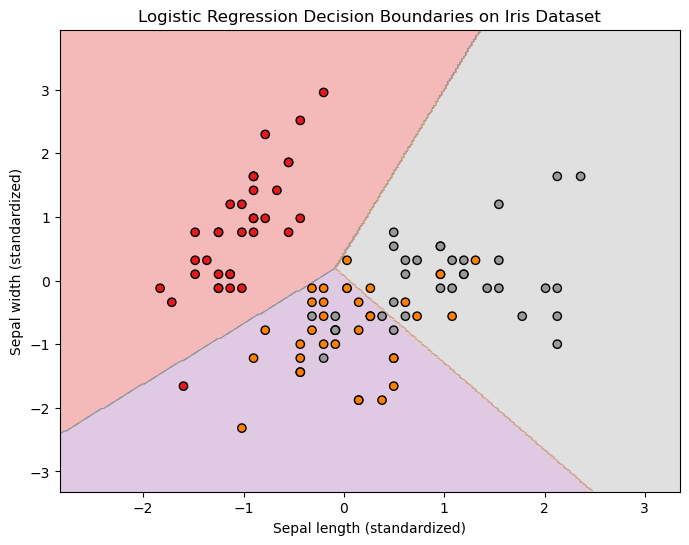

In [ ]:
x_min, x_max = X_train[:, 0].min() - 1, X_train[:, 0].max() + 1
y_min, y_max = X_train[:, 1].min() - 1, X_train[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))
Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8,6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.Set1)
plt.scatter(X_train[:, 0], X_train[:, 1], c=y_train, edgecolors='k', cmap=plt.cm.Set1)
plt.xlabel('Sepal length (standardized)')
plt.ylabel('Sepal width (standardized)')
plt.title('Logistic Regression Decision Boundaries on Iris Dataset')
plt.show()